# Unimodal Textual Sensitivity: Aggregation, Analysis & Figures

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

In [1]:
import os, json, warnings, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')

BASE_DIR = 'unimodal/text_corruptions'
BASELINE_CSV = 'evaluation/baseline_iou_all.csv'
OUTPUT_DIR = 'evaluation/textual'
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

## Constants & Mappings

In [2]:
ALL_CORRUPTIONS = [
    'fragmentation', 'character_noise', 'ata_saliency',
    'homophone', 'synonym',
    'universal_suffix', 'context_rot', 'reinforcement',
]

CATEGORY_MAP = {
    'fragmentation':    'Orthographic',
    'character_noise':  'Orthographic',
    'ata_saliency':     'Orthographic',
    'homophone':        'Semantic',
    'synonym':          'Semantic',
    'universal_suffix': 'Instruction',
    'context_rot':      'Instruction',
    'reinforcement':    'Instruction',
}

NICE_NAMES = {
    'fragmentation':    'Fragmentation',
    'character_noise':  'Character Noise',
    'ata_saliency':     'Lexical Saliency',
    'homophone':        'Homophone',
    'synonym':          'Synonym',
    'universal_suffix': 'Adversarial Suffix',
    'context_rot':      'Context Rot',
    'reinforcement':    'Task Reinforcement',
}

LABEL_LEVEL = ['fragmentation', 'character_noise', 'ata_saliency', 'homophone', 'synonym']
LABEL_LEVEL_SET = set(LABEL_LEVEL)
CATEGORY_ORDER = ['Orthographic', 'Semantic']

CORR_COLORS = {
    'fragmentation':    '#1f77b4',
    'character_noise':  '#ff7f0e',
    'ata_saliency':     '#2ca02c',
    'homophone':        '#d62728',
    'synonym':          '#9467bd',
}

CAT_COLORS = {
    'Orthographic': '#e41a1c',
    'Semantic':     '#377eb8',
}

SCENE_COLORS = {
    'Isolated':  '#4878A8',
    'Clustered': '#E8913A',
    'Mixed':     '#59A668',
}
SCENE_MARKERS = {'Isolated': 'o', 'Clustered': 's', 'Mixed': '^'}
SCENE_ORDER = ['Isolated', 'Clustered', 'Mixed']


def style_ax(ax, grid_major=True, grid_minor=False):
    """Apply shared axis styling matching Baseline_Evaluation.ipynb."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    if grid_major:
        ax.yaxis.grid(True, which='major', ls='-', lw=0.4, alpha=0.5)
        ax.xaxis.grid(False)
    if grid_minor:
        ax.yaxis.grid(True, which='minor', ls=':', lw=0.3, alpha=0.3)

## Load Baseline + Text Corruption Data

In [3]:
bl = pd.read_csv(BASELINE_CSV)
bl = bl.rename(columns={'iou': 'baseline_iou'})
bl_lookup = bl.set_index(['scene_type', 'sample_id'])['baseline_iou'].to_dict()
print(f'Baseline: {len(bl)} samples loaded')
print(bl.groupby('scene_type')['baseline_iou'].agg(['mean', 'std', 'count']).round(4))

Baseline: 750 samples loaded
              mean     std  count
scene_type                       
Clustered   0.8414  0.1261    250
Isolated    0.9226  0.0766    250
Mixed       0.7822  0.1339    250


In [4]:
def get_scene_type(rel_path):
    rel = rel_path.replace('\\', '/')
    if rel.startswith('single/solo'):  return 'Isolated'
    if rel.startswith('single/multi'): return 'Clustered'
    if rel.startswith('multi'):        return 'Mixed'
    return 'Unknown'

rows = []
missing = 0
errors = []

for root, dirs, files in os.walk(BASE_DIR):
    for fname in files:
        if not fname.startswith('scale_') or not fname.endswith('_TEXT.json'):
            continue
        fpath = os.path.join(root, fname)
        rel_path = os.path.relpath(root, BASE_DIR)
        sample_id = int(os.path.basename(root))
        scene_type = get_scene_type(rel_path)

        try:
            with open(fpath) as f:
                data = json.load(f)
        except Exception as e:
            errors.append((fpath, str(e))); missing += 1; continue

        sev = data['corruption_scale']
        sev_float = data.get('corruption_scale_float', sev / 4.0)

        for attack, m in data.get('corruptions', {}).items():
            rows.append({
                'sample_id': sample_id,
                'scene_type': scene_type,
                'corruption': attack,
                'severity': sev,
                'severity_float': sev_float,
                'IoU': m.get('IoU', 0.0),
                'cosine_similarity': m.get('cosine_similarity', np.nan),
                'token_count': m.get('token_count', 0),
                'raw_token_count': m.get('raw_token_count', 0),
                'runtime_seconds': m.get('runtime_seconds', 0.0),
            })

df_all = pd.DataFrame(rows)
df_all['category'] = df_all['corruption'].map(CATEGORY_MAP)
df_all['baseline_iou'] = df_all.apply(
    lambda r: bl_lookup.get((r.scene_type, r.sample_id), np.nan), axis=1
)

print(f'Rows (all 8): {len(df_all):,}  (expected {750 * 8 * 5:,})')
print(f'Missing/error files: {missing}')
print(f'Samples: {df_all.sample_id.nunique()}, Corruptions: {df_all.corruption.nunique()}')
print(f'Baseline matched: {df_all.baseline_iou.notna().sum():,} / {len(df_all):,}')
print(f'Cosine similarity present: {df_all.cosine_similarity.notna().sum():,} / {len(df_all):,}')
print()
print(df_all.groupby('scene_type')['sample_id'].nunique())

Rows (all 8): 30,000  (expected 30,000)
Missing/error files: 0
Samples: 250, Corruptions: 8
Baseline matched: 30,000 / 30,000
Cosine similarity present: 30,000 / 30,000

scene_type
Clustered    250
Isolated     250
Mixed        250
Name: sample_id, dtype: int64


In [5]:
df_all.to_csv(os.path.join(OUTPUT_DIR, 'unimodal_textual_flat.csv'), index=False)
print('saved flat csv (all 8 corruptions)')

saved flat csv (all 8 corruptions)


In [6]:
bl_means = bl.groupby('scene_type')['baseline_iou'].mean().to_dict()
bl_overall = bl['baseline_iou'].mean()
print(f'Baseline means: {bl_means}')
print(f'Overall: {bl_overall:.5f}')

Baseline means: {'Clustered': 0.84142396, 'Isolated': 0.92264948, 'Mixed': 0.7821761199999999}
Overall: 0.84875


## Per-Corruption Sensitivity -- Full Overview (All 8)

In [7]:
iou_pivot_all = df_all.pivot_table(
    index='corruption', columns='severity', values='IoU', aggfunc='mean'
).round(3)
iou_pivot_all.insert(0, 'BL', round(bl_overall, 3))
iou_pivot_all['drop_BL_to_4'] = (iou_pivot_all['BL'] - iou_pivot_all[4]).round(3)
iou_pivot_all['pct_drop'] = ((iou_pivot_all['drop_BL_to_4'] / iou_pivot_all['BL']) * 100).round(1)
iou_pivot_all = iou_pivot_all.sort_values('drop_BL_to_4', ascending=False)

print('=== Mean IoU - ALL 8 CORRUPTIONS (with Baseline) ===')
display(iou_pivot_all)

iou_pivot_all.to_csv(os.path.join(OUTPUT_DIR, 'table_iou_all_8_corruptions.csv'))

=== Mean IoU - ALL 8 CORRUPTIONS (with Baseline) ===


severity,BL,0,1,2,3,4,drop_BL_to_4,pct_drop
corruption,,,,,,,,
homophone,0.849,0.837,0.800,0.759,0.718,0.679,0.170,20.0
character_noise,0.849,0.845,0.832,0.800,0.763,0.691,0.158,18.6
ata_saliency,0.849,0.834,0.814,0.780,0.748,0.712,0.137,16.1
synonym,0.849,0.851,0.841,0.831,0.816,0.807,0.042,4.9
fragmentation,0.849,0.848,0.836,0.833,0.827,0.813,0.036,4.2
context_rot,0.849,0.839,0.843,0.842,0.846,0.843,0.006,0.7
universal_suffix,0.849,0.847,0.848,0.845,0.845,0.843,0.006,0.7
reinforcement,0.849,0.847,0.846,0.844,0.828,0.847,0.002,0.2


In [8]:
instr = df_all[df_all.corruption.isin({'universal_suffix', 'context_rot', 'reinforcement'})]
instr_s4 = instr[instr.severity == 4]

print('=== Instruction-Level Corruptions at S4 - Summary ===')
print(f'  Mean IoU:  {instr_s4["IoU"].mean():.4f}  (baseline: {bl_overall:.4f})')
print(f'  Max drop:  {(bl_overall - instr_s4.groupby("corruption")["IoU"].mean().min()):.4f}')
print(f'  CosSim:    {instr_s4["cosine_similarity"].mean():.4f}  (labels untouched -> 1.0)')
print()
for c in ['universal_suffix', 'context_rot', 'reinforcement']:
    sub = instr_s4[instr_s4.corruption == c]
    print(f'  {NICE_NAMES[c]:25s}  IoU={sub["IoU"].mean():.4f}  '
          f'({(bl_overall - sub["IoU"].mean()) / bl_overall * 100:.1f}% drop)')

print()
print('Instruction-level corruptions do not modify the class label and produce')
print('negligible detection degradation. Excluded from all subsequent analysis.')

=== Instruction-Level Corruptions at S4 - Summary ===
  Mean IoU:  0.8443  (baseline: 0.8487)
  Max drop:  0.0062
  CosSim:    1.0000  (labels untouched -> 1.0)

  Adversarial Suffix         IoU=0.8426  (0.7% drop)
  Context Rot                IoU=0.8432  (0.7% drop)
  Task Reinforcement         IoU=0.8472  (0.2% drop)

Instruction-level corruptions do not modify the class label and produce
negligible detection degradation. Excluded from all subsequent analysis.


In [9]:
df = df_all[df_all.corruption.isin(LABEL_LEVEL_SET)].copy()

print(f'Filtered to label-level only: {len(df):,} rows '
      f'(expected {750 * 5 * 5:,})')
print(f'Corruptions: {sorted(df.corruption.unique())}')

Filtered to label-level only: 18,750 rows (expected 18,750)
Corruptions: ['ata_saliency', 'character_noise', 'fragmentation', 'homophone', 'synonym']


## Per-Corruption Sensitivity Profiles (Label-Level Only)

In [10]:
iou_pivot = df.pivot_table(
    index='corruption', columns='severity', values='IoU', aggfunc='mean'
).round(3)
iou_pivot.insert(0, 'BL', round(bl_overall, 3))
iou_pivot['drop_BL_to_4'] = (iou_pivot['BL'] - iou_pivot[4]).round(3)
iou_pivot['pct_drop'] = ((iou_pivot['drop_BL_to_4'] / iou_pivot['BL']) * 100).round(1)
iou_pivot = iou_pivot.sort_values('drop_BL_to_4', ascending=False)

print('=== Mean IoU - Label-Level Corruptions ===')
display(iou_pivot)

iou_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_iou_per_corruption.csv'))

=== Mean IoU - Label-Level Corruptions ===


severity,BL,0,1,2,3,4,drop_BL_to_4,pct_drop
corruption,,,,,,,,
homophone,0.849,0.837,0.800,0.759,0.718,0.679,0.170,20.0
character_noise,0.849,0.845,0.832,0.800,0.763,0.691,0.158,18.6
ata_saliency,0.849,0.834,0.814,0.780,0.748,0.712,0.137,16.1
synonym,0.849,0.851,0.841,0.831,0.816,0.807,0.042,4.9
fragmentation,0.849,0.848,0.836,0.833,0.827,0.813,0.036,4.2


In [11]:
cos_pivot = df.pivot_table(
    index='corruption', columns='severity', values='cosine_similarity', aggfunc='mean'
).round(3)
cos_pivot = cos_pivot.reindex([c for c in LABEL_LEVEL if c in cos_pivot.index])

print('=== Mean Cosine Similarity - Label-Level Corruptions ===')
display(cos_pivot)

cos_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_cosine_per_corruption.csv'))

=== Mean Cosine Similarity - Label-Level Corruptions ===


severity,0,1,2,3,4
corruption,,,,,
fragmentation,0.983,0.948,0.909,0.880,0.840
character_noise,0.931,0.855,0.803,0.771,0.744
ata_saliency,0.969,0.919,0.870,0.807,0.754
homophone,0.973,0.926,0.874,0.827,0.779
synonym,0.985,0.949,0.910,0.872,0.838


## Degradation Curves

In [12]:
x_labels = ['BL', '0', '1', '2', '3', '4']
x_pos = np.array([-0.5, 0, 1, 2, 3, 4])

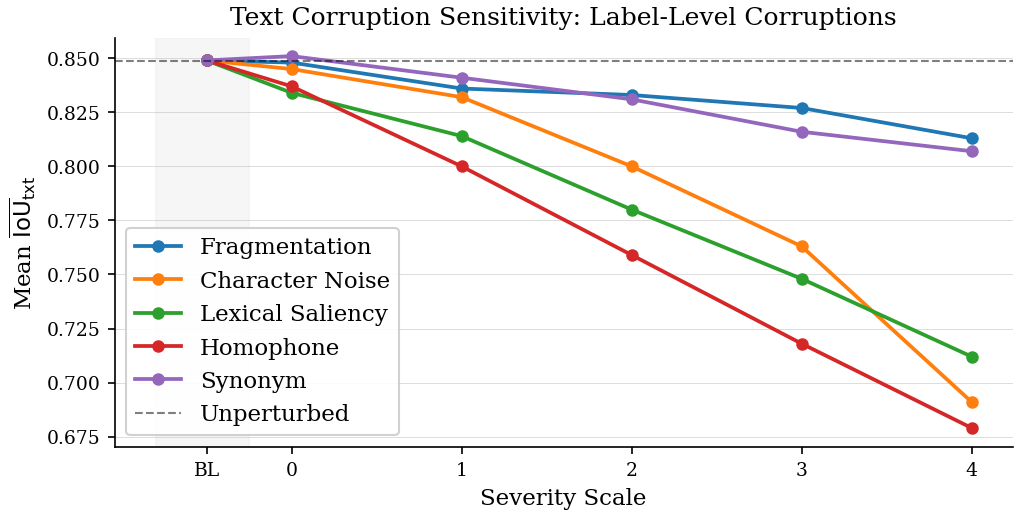

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.65))

for corr in LABEL_LEVEL:
    if corr not in iou_pivot.index:
        continue
    vals = [iou_pivot.loc[corr, 'BL']] + [iou_pivot.loc[corr, s] for s in [0, 1, 2, 3, 4]]
    ax.plot(x_pos, vals, marker='o', markersize=5, linewidth=1.8,
            color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

ax.axhline(bl_overall, color='black', ls='--', lw=1, alpha=0.5, label='Unperturbed')
ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean $\\overline{\mathrm{IoU}}_\mathrm{txt}$')
ax.set_title('Text Corruption Sensitivity: Label-Level Corruptions')
ax.legend(loc='lower left', framealpha=0.9, fontsize=11)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_label_level.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_label_level.png'))
plt.show()

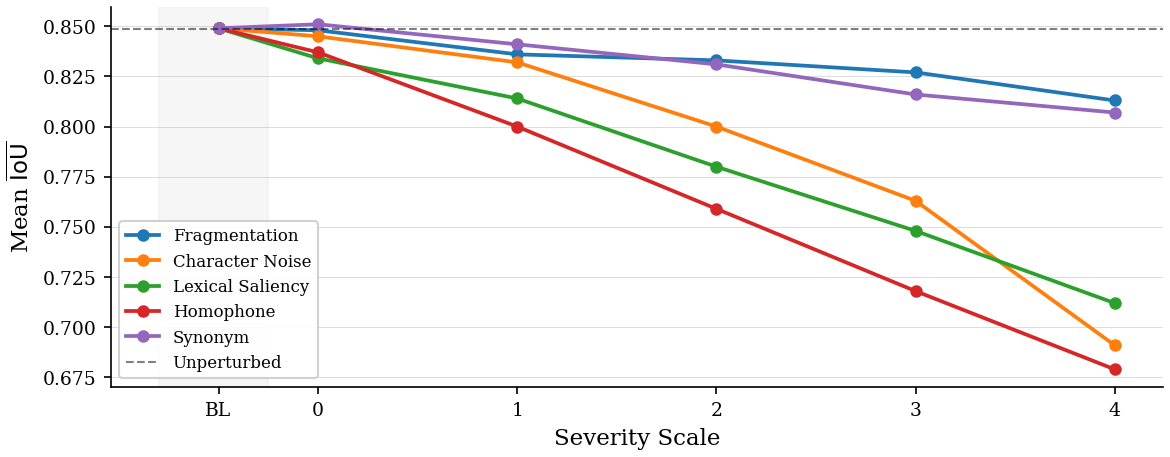

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.25))

for corr in LABEL_LEVEL:
    if corr not in iou_pivot.index:
        continue
    vals = [iou_pivot.loc[corr, 'BL']] + [iou_pivot.loc[corr, s] for s in [0, 1, 2, 3, 4]]
    ax.plot(x_pos, vals, marker='o', markersize=5, linewidth=1.8,
            color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

ax.axhline(bl_overall, color='black', ls='--', lw=1, alpha=0.5, label='Unperturbed')
ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean $\\overline{\mathrm{IoU}}$')
ax.set_title('')
ax.legend(loc='lower left', framealpha=0.9, fontsize=8)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_label_level_notitle.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_label_level_notitle.png'))
plt.show()

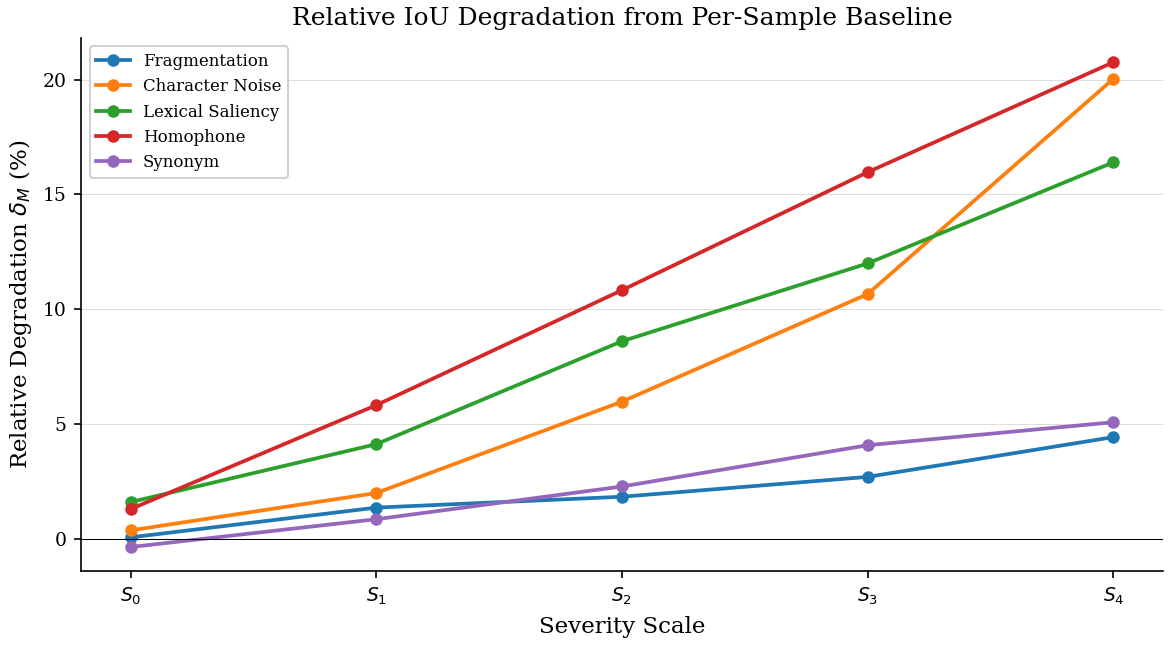

In [15]:
rel_deg = df.groupby(['corruption', 'severity']).apply(
    lambda g: ((g['baseline_iou'] - g['IoU']) / g['baseline_iou']).mean() * 100
).reset_index(name='pct_degradation')

fig, ax = plt.subplots(figsize=(8, 4.5))

for corr in LABEL_LEVEL:
    sub = rel_deg[rel_deg.corruption == corr].sort_values('severity')
    ax.plot(sub['severity'], sub['pct_degradation'],
            marker='o', markersize=5, linewidth=1.8,
            color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Relative Degradation $\\delta_M$ (%)')
ax.set_title('Relative IoU Degradation from Per-Sample Baseline')
ax.legend(loc='upper left', framealpha=0.9, fontsize=8)
ax.set_xticks(range(5))
ax.set_xticklabels(['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$'])
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_relative_degradation.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_relative_degradation.png'))
plt.show()

## Cosine Similarity (Semantic Stealth) Analysis

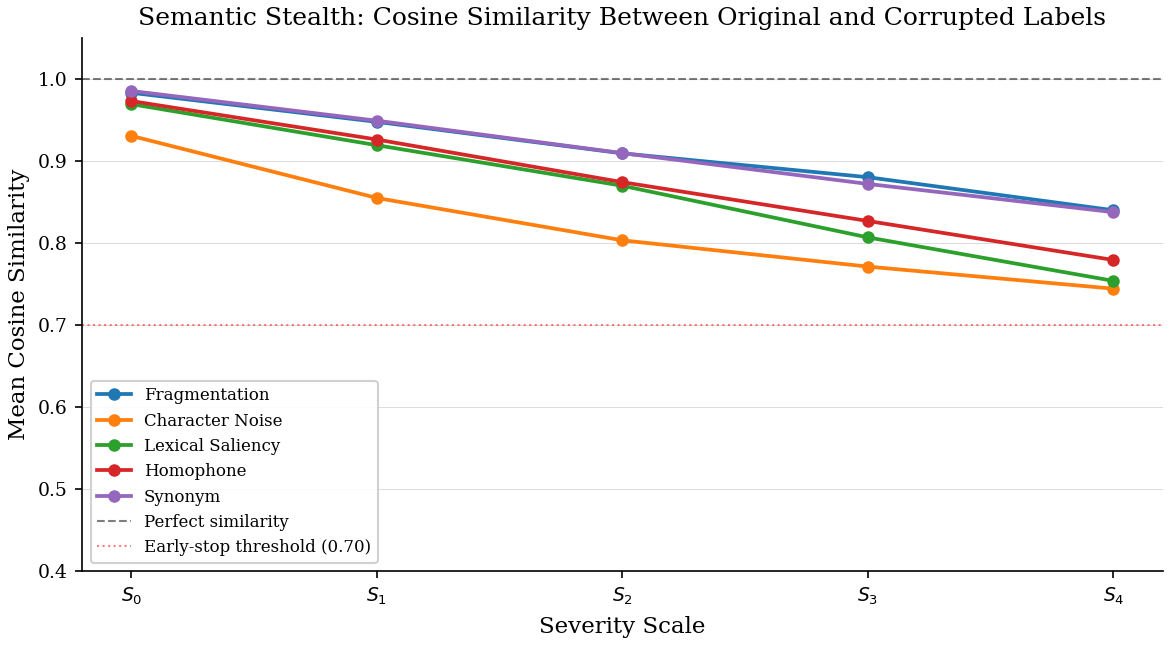

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for corr in LABEL_LEVEL:
    sub = df[df.corruption == corr].groupby('severity')['cosine_similarity'].mean()
    if sub.isna().all():
        continue
    ax.plot(sub.index, sub.values, marker='o', markersize=5, linewidth=1.8,
            color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

ax.axhline(1.0, color='black', ls='--', lw=1, alpha=0.5, label='Perfect similarity')
ax.axhline(0.70, color='red', ls=':', lw=1, alpha=0.5,
           label='Early-stop threshold (0.70)')
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean Cosine Similarity')
ax.set_title('Semantic Stealth: Cosine Similarity Between Original and Corrupted Labels')
ax.set_xticks(range(5))
ax.set_xticklabels(['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$'])
ax.set_ylim(0.4, 1.05)
ax.legend(loc='lower left', framealpha=0.9, fontsize=8)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_cosine_similarity_curves.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_cosine_similarity_curves.png'))
plt.show()

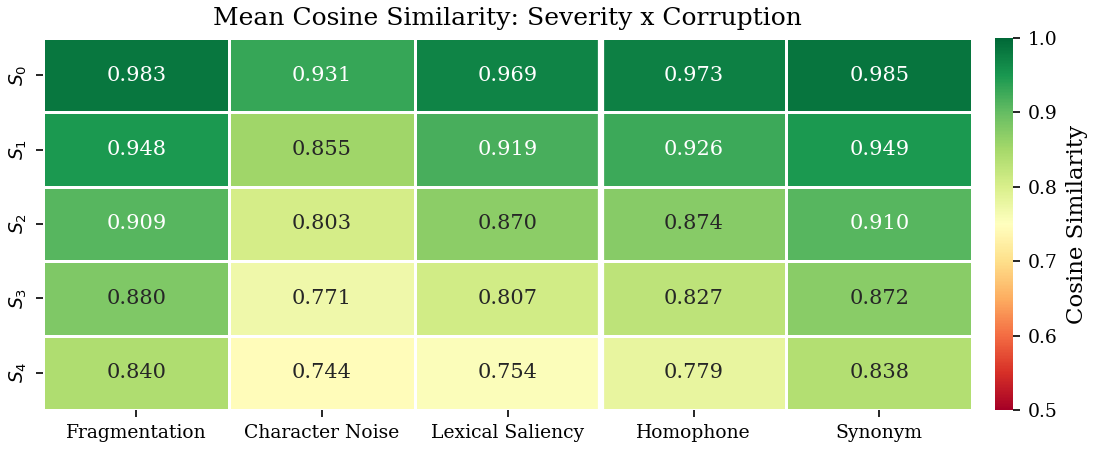

In [17]:
cos_heat = df.pivot_table(
    index='corruption', columns='severity', values='cosine_similarity', aggfunc='mean'
)
cos_heat = cos_heat.reindex([c for c in LABEL_LEVEL if c in cos_heat.index])
cos_heat.index = [NICE_NAMES.get(c, c) for c in cos_heat.index]
cos_heat.columns = ['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$']

cos_heat_T = cos_heat.T

fig, ax = plt.subplots(figsize=(8, 3.2))
sns.heatmap(cos_heat_T, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Cosine Similarity', 'pad': 0.02})
ax.set_title('Mean Cosine Similarity: Severity x Corruption')
ax.set_xlabel('')
ax.set_ylabel('')

ax.axvline(3, color='white', lw=3)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_cosine_heatmap.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_cosine_heatmap.png'))
plt.show()

In [18]:
cos_table = df.pivot_table(
    index='corruption', columns='severity', values='cosine_similarity', aggfunc='mean'
).round(3)
cos_table = cos_table.reindex([c for c in LABEL_LEVEL if c in cos_table.index])
cos_table.index = [NICE_NAMES.get(c, c) for c in cos_table.index]
cos_table.columns = [
    f"$\\mathrm{{sim}}_{{\\mathrm{{txt}}}}(P,\\, P'_{{S_{i}}})$"
    for i in range(5)
]

print('=== Mean Cosine Similarity per Corruption × Severity ===')
display(cos_table)
print()
print(cos_table.to_markdown())

=== Mean Cosine Similarity per Corruption × Severity ===


,"$\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_0})$","$\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_1})$","$\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_2})$","$\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_3})$","$\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_4})$"
Fragmentation,0.983,0.948,0.909,0.880,0.840
Character Noise,0.931,0.855,0.803,0.771,0.744
Lexical Saliency,0.969,0.919,0.870,0.807,0.754
Homophone,0.973,0.926,0.874,0.827,0.779
Synonym,0.985,0.949,0.910,0.872,0.838



|                  |   $\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_0})$ |   $\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_1})$ |   $\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_2})$ |   $\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_3})$ |   $\mathrm{sim}_{\mathrm{txt}}(P,\, P'_{S_4})$ |
|:-----------------|-----------------------------------------------:|-----------------------------------------------:|-----------------------------------------------:|-----------------------------------------------:|-----------------------------------------------:|
| Fragmentation    |                                          0.983 |                                          0.948 |                                          0.909 |                                          0.88  |                                          0.84  |
| Character Noise  |                                          0.931 |                                          0.855 |                                          0.803 |                                  

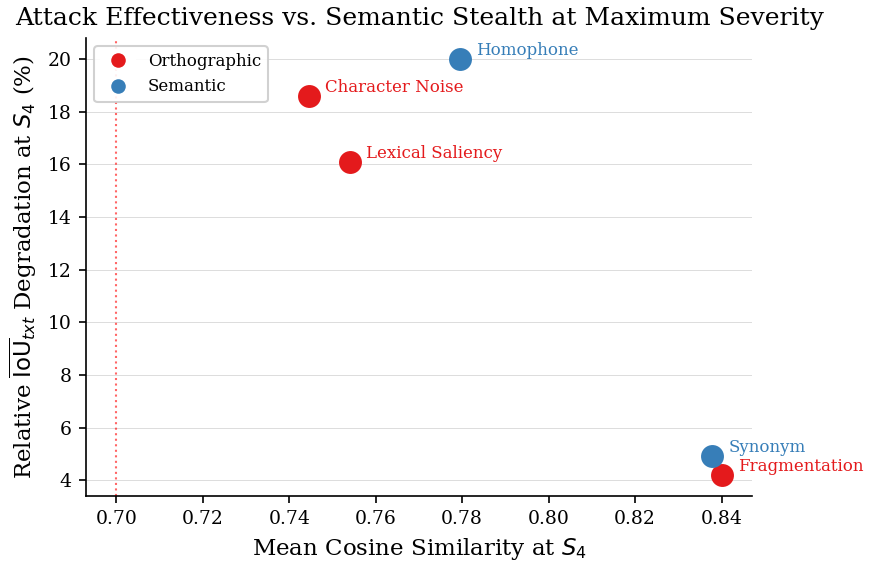

In [19]:
sev4 = df[df.severity == 4].copy()
sev4_agg = sev4.groupby('corruption').agg(
    mean_iou=('IoU', 'mean'),
    mean_cos=('cosine_similarity', 'mean'),
).reset_index()
sev4_agg['pct_drop'] = ((bl_overall - sev4_agg['mean_iou']) / bl_overall * 100)
sev4_agg['category'] = sev4_agg['corruption'].map(CATEGORY_MAP)

fig, ax = plt.subplots(figsize=(6, 4))

for _, row in sev4_agg.iterrows():
    ax.plot(row['mean_cos'], row['pct_drop'],
            marker='o', ms=10,
            color=CAT_COLORS[row['category']],
            linestyle='none', zorder=5)
    ax.annotate(NICE_NAMES.get(row['corruption'], row['corruption']),
                (row['mean_cos'], row['pct_drop']),
                textcoords='offset points', xytext=(8, 2),
                fontsize=8, color=CAT_COLORS[row['category']])

ax.axvline(0.70, color='red', ls=':', lw=1, alpha=0.6, label='Stealth threshold (0.70)')

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=col,
                   markersize=8, label=cat)
           for cat, col in CAT_COLORS.items()]
ax.legend(handles=handles, loc='upper left', framealpha=0.9, fontsize=8)

ax.set_xlabel('Mean Cosine Similarity at $S_4$')
ax.set_ylabel('Relative $\\overline{\\mathrm{IoU}}_{txt}$ Degradation at $S_4$ (%)')
ax.set_title('Attack Effectiveness vs. Semantic Stealth at Maximum Severity')
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_effectiveness_vs_stealth.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_effectiveness_vs_stealth.png'))
plt.show()

## Corruption Category Analysis (Orthographic vs Semantic)

In [20]:
cat_pivot = df.pivot_table(
    index='category', columns='severity', values='IoU', aggfunc='mean'
).round(3)
cat_pivot.insert(0, 'BL', round(bl_overall, 3))
cat_pivot['drop_BL_to_4'] = (cat_pivot['BL'] - cat_pivot[4]).round(3)
cat_pivot['pct_drop'] = ((cat_pivot['drop_BL_to_4'] / cat_pivot['BL']) * 100).round(1)
cat_pivot = cat_pivot.reindex(CATEGORY_ORDER)

print('=== Category-Level IoU ===')
display(cat_pivot)

cat_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_category_iou.csv'))

=== Category-Level IoU ===


severity,BL,0,1,2,3,4,drop_BL_to_4,pct_drop
category,,,,,,,,
Orthographic,0.849,0.842,0.827,0.804,0.779,0.739,0.110,13.0
Semantic,0.849,0.844,0.820,0.795,0.767,0.743,0.106,12.5


In [21]:
cat_cos_pivot = df.pivot_table(
    index='category', columns='severity', values='cosine_similarity', aggfunc='mean'
).round(3)
cat_cos_pivot = cat_cos_pivot.reindex(CATEGORY_ORDER)

print('=== Category-Level Cosine Similarity ===')
display(cat_cos_pivot)

cat_cos_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_category_cosine.csv'))

=== Category-Level Cosine Similarity ===


severity,0,1,2,3,4
category,,,,,
Orthographic,0.961,0.907,0.861,0.82,0.780
Semantic,0.979,0.938,0.892,0.85,0.809


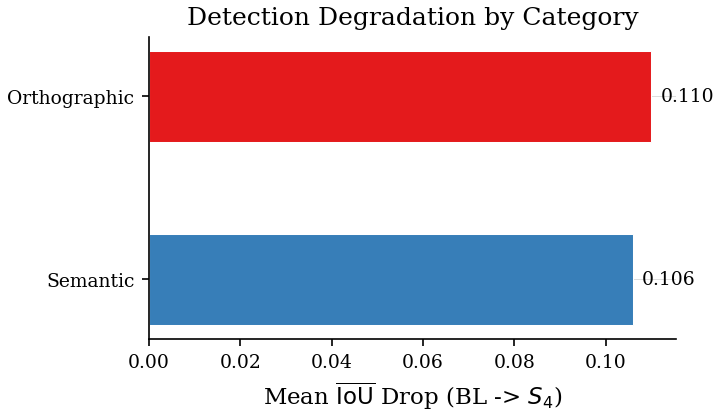

In [22]:
fig, ax = plt.subplots(figsize=(5, 3))

cats = cat_pivot.index.tolist()
drops = cat_pivot['drop_BL_to_4'].values
colors = [CAT_COLORS[c] for c in cats]

bars = ax.barh(cats, drops, color=colors, edgecolor='white', linewidth=0.5, height=0.5)

for bar, val in zip(bars, drops):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Mean $\\overline{\mathrm{IoU}}$ Drop (BL -> $S_4$)')
ax.set_title('Detection Degradation by Category')
ax.invert_yaxis()
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_bar_drop.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_bar_drop.png'))
plt.show()

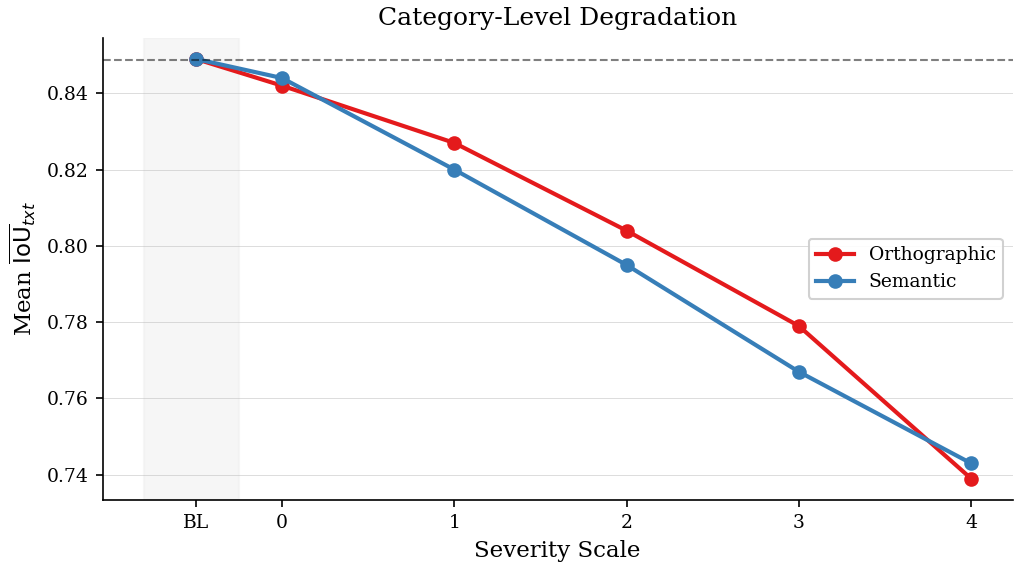

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))

for cat in CATEGORY_ORDER:
    vals = [cat_pivot.loc[cat, 'BL']] + [cat_pivot.loc[cat, s] for s in [0, 1, 2, 3, 4]]
    ax.plot(x_pos, vals, marker='o', markersize=6, linewidth=2,
            color=CAT_COLORS[cat], label=cat)

ax.axhline(bl_overall, color='black', ls='--', lw=1, alpha=0.5)
ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean $\\overline{\\mathrm{IoU}}_{txt}$')
ax.set_title('Category-Level Degradation')
ax.legend(framealpha=0.9)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_degradation.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_degradation.png'))
plt.show()

## Scene-Type Sensitivity

In [24]:
sev4_scene = df[df.severity == 4].pivot_table(
    index='corruption', columns='scene_type', values='IoU', aggfunc='mean'
).round(3)
sev4_scene = sev4_scene[SCENE_ORDER]
sev4_scene = sev4_scene.sort_values('Mixed', ascending=True)

print('=== Mean IoU at Severity 4, per Corruption x Scene Type ===')
display(sev4_scene)

sev4_scene.to_csv(os.path.join(OUTPUT_DIR, 'table_scene_type_iou_sev4.csv'))

=== Mean IoU at Severity 4, per Corruption x Scene Type ===


scene_type,Isolated,Clustered,Mixed
corruption,,,
character_noise,0.862,0.718,0.493
homophone,0.854,0.658,0.525
ata_saliency,0.864,0.664,0.609
synonym,0.911,0.779,0.730
fragmentation,0.905,0.801,0.733


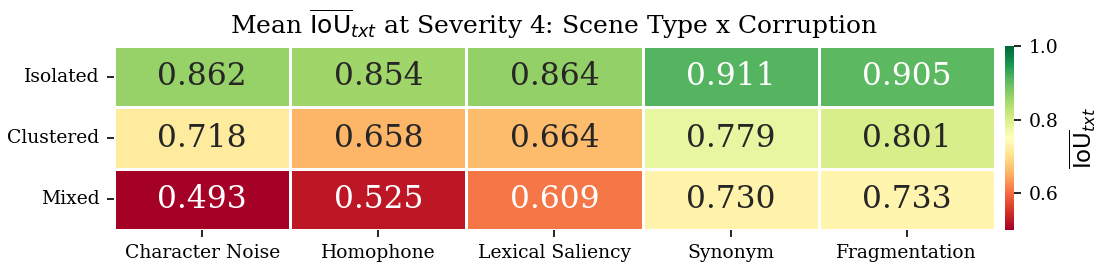

In [25]:
heat_data = sev4_scene.copy()
heat_data.index = [NICE_NAMES.get(c, c) for c in heat_data.index]

heat_data_T = heat_data.T

fig, ax = plt.subplots(figsize=(8, 2.0))
sns.heatmap(heat_data_T, annot=True, fmt='.3f', annot_kws={'fontsize': 15},
            cmap='RdYlGn', vmin=0.5, vmax=1.0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '$\\overline{\\mathrm{IoU}}_{txt}$', 'pad': 0.01})
ax.set_title('Mean $\\overline{\\mathrm{IoU}}_{txt}$ at Severity 4: Scene Type x Corruption')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_heatmap_sev4_scene_text.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_heatmap_sev4_scene_text.png'))
plt.show()

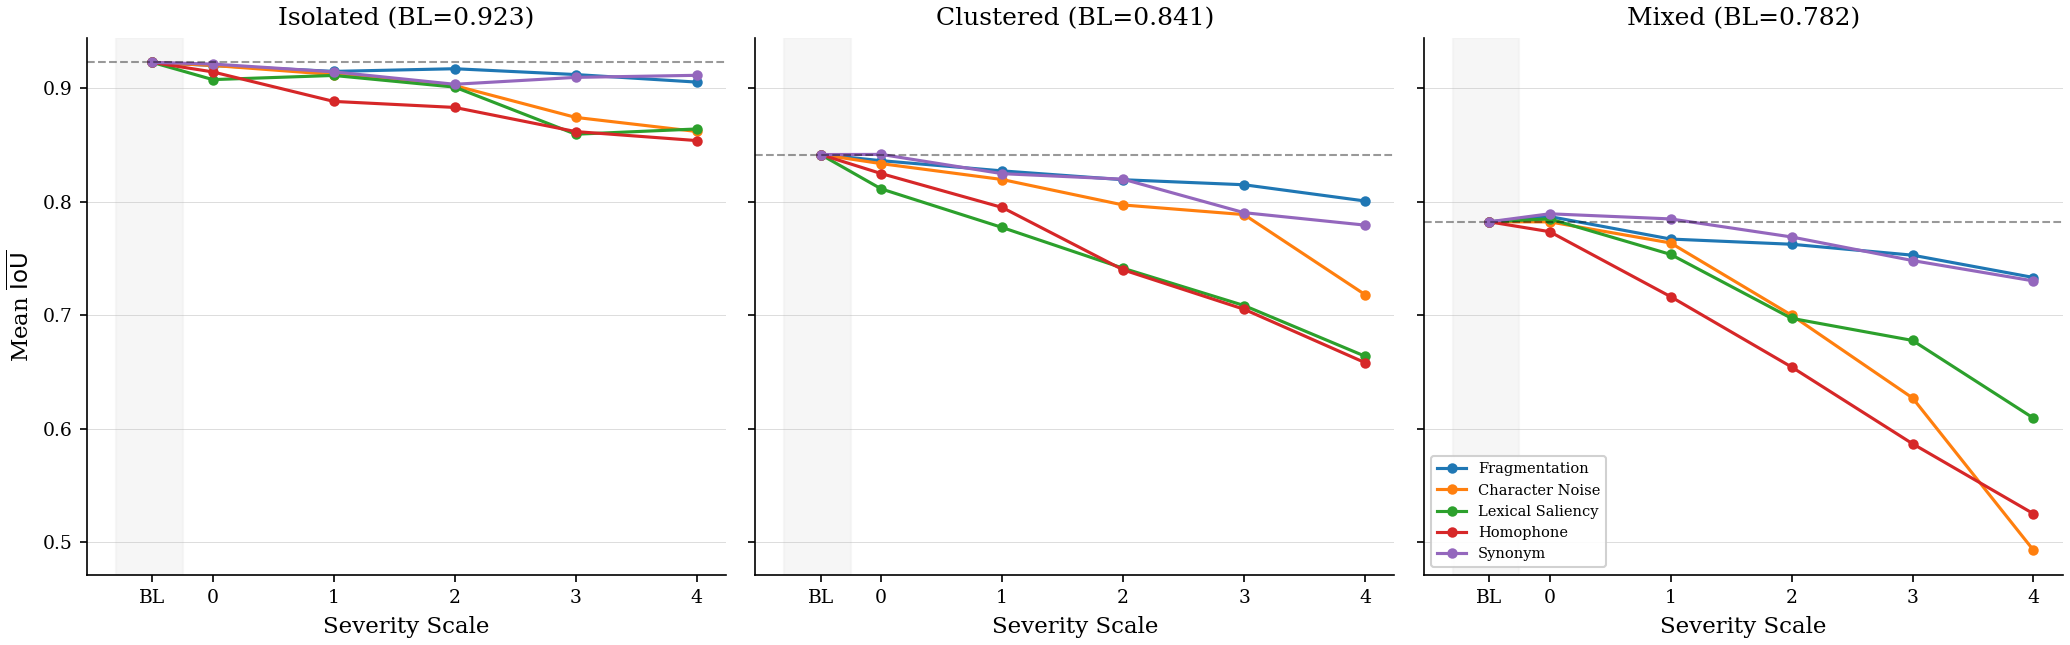

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, scene in zip(axes, SCENE_ORDER):
    sub = df[df.scene_type == scene]
    scene_bl = bl_means[scene]

    for corr in LABEL_LEVEL:
        csub = sub[sub.corruption == corr].groupby('severity')['IoU'].mean()
        vals = [scene_bl] + csub.tolist()
        ax.plot(x_pos, vals, marker='o', markersize=4, linewidth=1.5,
                color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

    ax.axhline(scene_bl, color='black', ls='--', lw=1, alpha=0.4)
    ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Severity Scale')
    ax.set_title(f'{scene} (BL={scene_bl:.3f})')
    style_ax(ax)

axes[0].set_ylabel('Mean $\\overline{\mathrm{IoU}}$')
axes[2].legend(loc='lower left', framealpha=0.9, fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_facets.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_facets.png'))
plt.show()

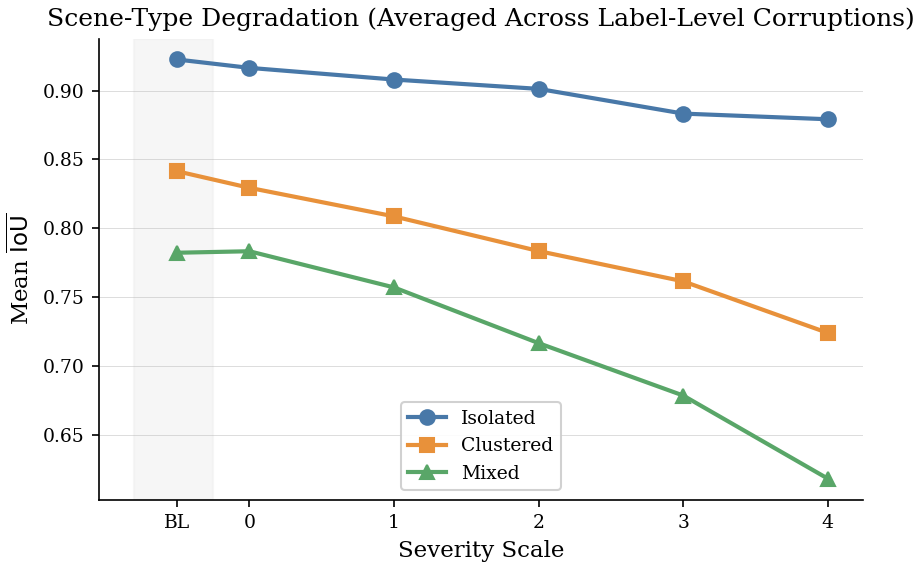

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))

for scene in SCENE_ORDER:
    sub = df[df.scene_type == scene].groupby('severity')['IoU'].mean()
    scene_bl = bl_means[scene]
    vals = [scene_bl] + sub.tolist()
    ax.plot(x_pos, vals, marker=SCENE_MARKERS[scene], markersize=7, linewidth=2,
            color=SCENE_COLORS[scene], label=scene)

ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean $\\overline{\mathrm{IoU}}$')
ax.set_title('Scene-Type Degradation (Averaged Across Label-Level Corruptions)')
ax.legend(framealpha=0.9)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_overall.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_overall.png'))
plt.show()

## IoU Distribution at S4 -- KDE vs Baseline

Top 3 most damaging label-level at sev 4: ['homophone', 'character_noise', 'ata_saliency']


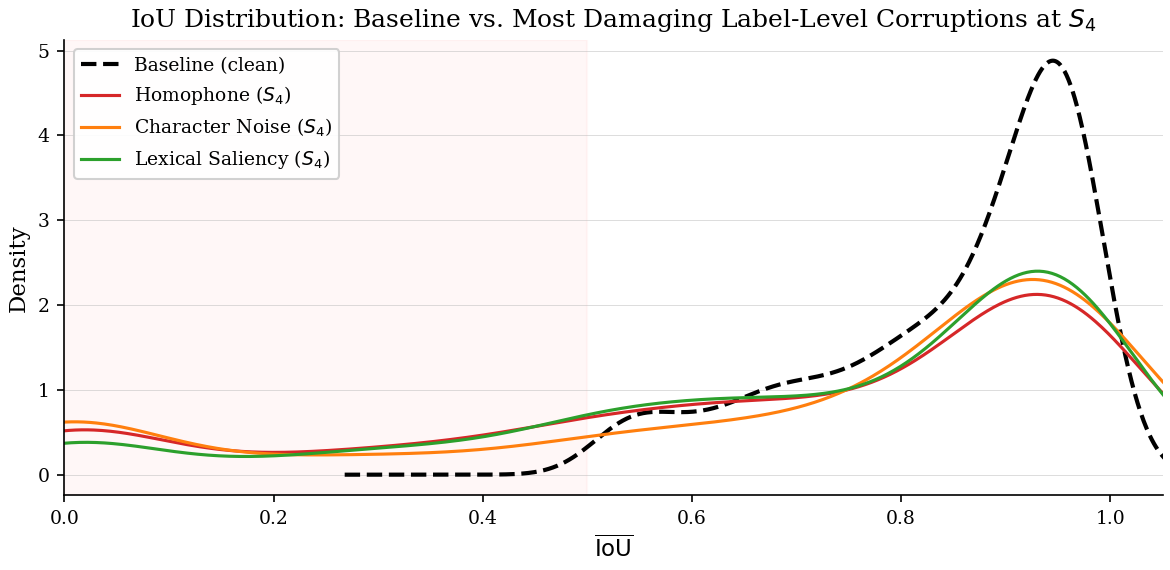

In [28]:
sev4_rank = df[df.severity == 4].groupby('corruption')['IoU'].mean().sort_values()
top_damaging = sev4_rank.head(3).index.tolist()
print('Top 3 most damaging label-level at sev 4:', top_damaging)

fig, ax = plt.subplots(figsize=(8, 4))

bl['baseline_iou'].plot.kde(ax=ax, color='black', ls='--', lw=2, label='Baseline (clean)')

for corr in top_damaging:
    sub = df[(df.corruption == corr) & (df.severity == 4)]
    sub['IoU'].plot.kde(ax=ax, color=CORR_COLORS[corr], lw=1.5,
                        label=f'{NICE_NAMES.get(corr, corr)} ($S_4$)')

ax.axvspan(0, 0.5, color='#ffcccc', alpha=0.15, zorder=0)
ax.set_xlim(0, 1.05)
ax.set_xlabel('$\\overline{\mathrm{IoU}}$')
ax.set_ylabel('Density')
ax.set_title('IoU Distribution: Baseline vs. Most Damaging Label-Level Corruptions at $S_4$')
ax.legend(framealpha=0.9)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_kde_baseline_vs_top3.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_kde_baseline_vs_top3.png'))
plt.show()

## Retention Summary

In [29]:
ret_rows = []
for corr in LABEL_LEVEL:
    s0 = df[(df.corruption == corr) & (df.severity == 0)]['IoU'].mean()
    s4 = df[(df.corruption == corr) & (df.severity == 4)]['IoU'].mean()
    cos_s4 = df[(df.corruption == corr) & (df.severity == 4)]['cosine_similarity'].mean()
    drop = bl_overall - s4
    pct = drop / bl_overall * 100
    ret_rows.append({
        'corruption': corr,
        'category': CATEGORY_MAP[corr],
        'nice_name': NICE_NAMES[corr],
        'baseline_iou': round(bl_overall, 5),
        'iou_s0': round(s0, 5),
        'iou_s4': round(s4, 5),
        'drop_bl_to_s4': round(drop, 5),
        'pct_drop': round(pct, 2),
        'cos_sim_s4': round(cos_s4, 4) if not np.isnan(cos_s4) else np.nan,
    })

ret_df = pd.DataFrame(ret_rows).set_index('corruption')
ret_df = ret_df.sort_values('drop_bl_to_s4', ascending=False)
display(ret_df)

ret_df.to_csv(os.path.join(OUTPUT_DIR, 'table_retention.csv'))

,category,nice_name,baseline_iou,iou_s0,iou_s4,drop_bl_to_s4,pct_drop,cos_sim_s4
corruption,,,,,,,,
homophone,Semantic,Homophone,0.84875,0.83747,0.67890,0.16985,20.01,0.7794
character_noise,Orthographic,Character Noise,0.84875,0.84518,0.69085,0.15790,18.60,0.7445
ata_saliency,Orthographic,Lexical Saliency,0.84875,0.83446,0.71228,0.13647,16.08,0.7540
synonym,Semantic,Synonym,0.84875,0.85066,0.80686,0.04189,4.94,0.8377
fragmentation,Orthographic,Fragmentation,0.84875,0.84758,0.81296,0.03579,4.22,0.8401


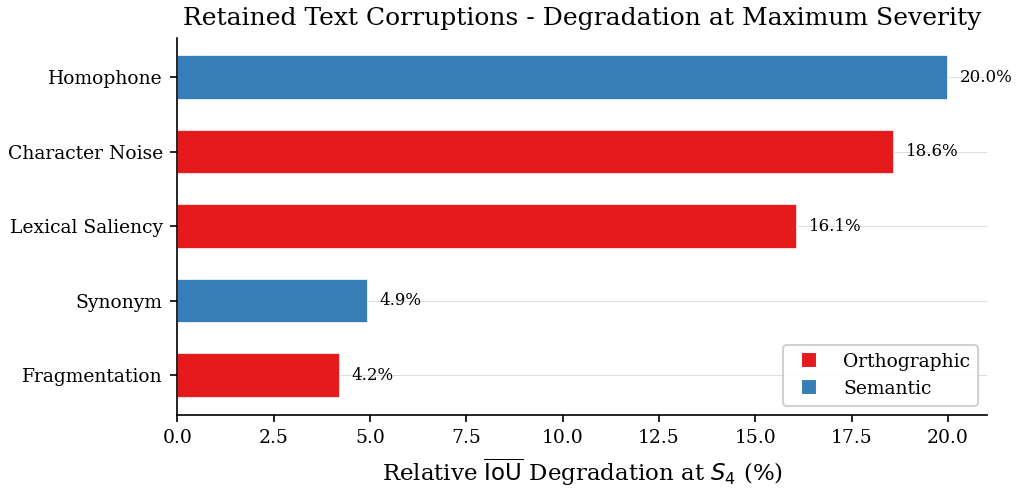

In [30]:
fig, ax = plt.subplots(figsize=(7, 3.5))

ret_sorted = ret_df.sort_values('pct_drop', ascending=True)
y_positions = range(len(ret_sorted))
labels = [ret_sorted.loc[c, 'nice_name'] for c in ret_sorted.index]
pcts = ret_sorted['pct_drop'].values
colors = [CAT_COLORS[ret_sorted.loc[c, 'category']] for c in ret_sorted.index]

bars = ax.barh(y_positions, pcts, color=colors, edgecolor='white',
               linewidth=0.8, height=0.6)

for bar, val in zip(bars, pcts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel('Relative $\\overline{\mathrm{IoU}}$ Degradation at $S_4$ (%)')
ax.set_title('Retained Text Corruptions - Degradation at Maximum Severity')

handles = [Line2D([0], [0], marker='s', color='w', markerfacecolor=col,
                   markersize=8, label=cat)
           for cat, col in CAT_COLORS.items()]
ax.legend(handles=handles, loc='lower right', framealpha=0.9)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_horizontal.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_horizontal.png'))
plt.show()

## Inference Efficiency (Token Count & Runtime)

In [31]:
bl_tok_mean = bl['token_count'].mean() if 'token_count' in bl.columns else np.nan
bl_raw_mean = bl['raw_token_count'].mean() if 'raw_token_count' in bl.columns else np.nan
print(f'Baseline visible tokens: {bl_tok_mean:.1f}')
print(f'Baseline raw tokens:     {bl_raw_mean:.1f}')

Baseline visible tokens: 103.3
Baseline raw tokens:     419.1


In [32]:
tok_pivot = df.pivot_table(
    index='corruption', columns='severity', values='token_count', aggfunc='mean'
).round(1)
tok_pivot = tok_pivot.reindex([c for c in LABEL_LEVEL if c in tok_pivot.index])
tok_pivot.index = [NICE_NAMES.get(c, c) for c in tok_pivot.index]

raw_tok_pivot = df.pivot_table(
    index='corruption', columns='severity', values='raw_token_count', aggfunc='mean'
).round(1)
raw_tok_pivot = raw_tok_pivot.reindex([c for c in LABEL_LEVEL if c in raw_tok_pivot.index])
raw_tok_pivot.index = [NICE_NAMES.get(c, c) for c in raw_tok_pivot.index]

print('=== Mean Visible Token Count ===')
display(tok_pivot)
print()
print('=== Mean Raw Token Count (incl. thinking) ===')
display(raw_tok_pivot)

tok_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_token_count.csv'))
raw_tok_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_raw_token_count.csv'))

=== Mean Visible Token Count ===


severity,0,1,2,3,4
Fragmentation,103.9,103.3,102.1,101.8,101.2
Character Noise,106.9,114.8,119.8,127.9,131.5
Lexical Saliency,102.7,99.1,94.5,92.5,90.1
Homophone,101.8,98.5,95.8,86.5,84.5
Synonym,104.4,102.8,97.4,94.8,96.3



=== Mean Raw Token Count (incl. thinking) ===


severity,0,1,2,3,4
Fragmentation,249.3,247.9,244.5,246.2,254.9
Character Noise,258.3,281.1,288.4,311.7,314.1
Lexical Saliency,250.7,239.1,232.9,235.1,219.6
Homophone,243.2,241.8,237.6,214.3,208.8
Synonym,250.2,246.4,229.5,220.7,228.6


In [33]:
rt_pivot = df.pivot_table(
    index='corruption', columns='severity', values='runtime_seconds', aggfunc='mean'
).round(3)
rt_pivot = rt_pivot.reindex([c for c in LABEL_LEVEL if c in rt_pivot.index])
rt_pivot.index = [NICE_NAMES.get(c, c) for c in rt_pivot.index]

print('=== Mean Runtime (seconds) ===')
display(rt_pivot)

rt_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_runtime.csv'))

=== Mean Runtime (seconds) ===


severity,0,1,2,3,4
Fragmentation,1.914,1.327,1.092,1.285,1.958
Character Noise,1.971,1.492,1.279,1.629,2.411
Lexical Saliency,1.915,1.256,1.049,1.219,1.703
Homophone,1.860,1.273,1.062,1.135,1.620
Synonym,1.915,1.298,1.031,1.174,1.756


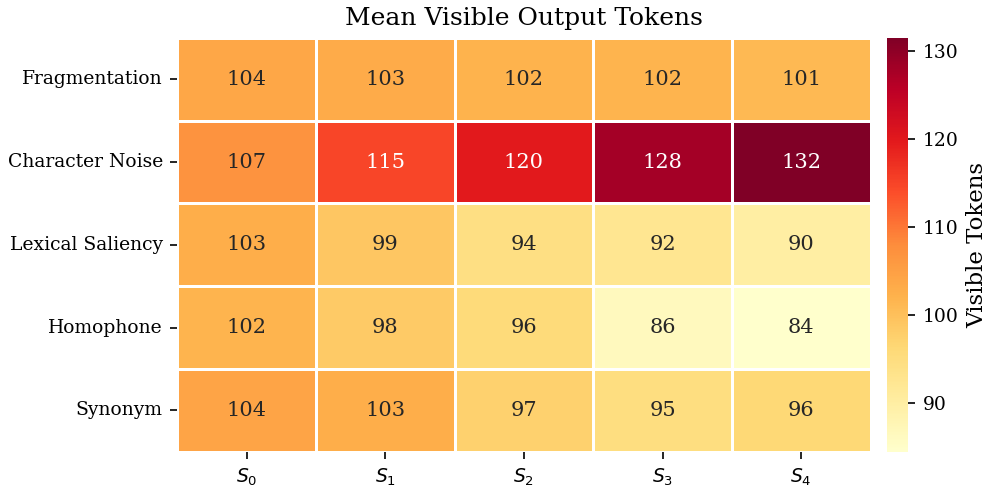

In [34]:
heat_tok = tok_pivot.copy()
heat_tok.columns = ['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$']

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(heat_tok, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Visible Tokens', 'pad': 0.02})
ax.set_title('Mean Visible Output Tokens')
ax.set_ylabel('')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_efficiency_heatmap.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_efficiency_heatmap.png'))
plt.show()

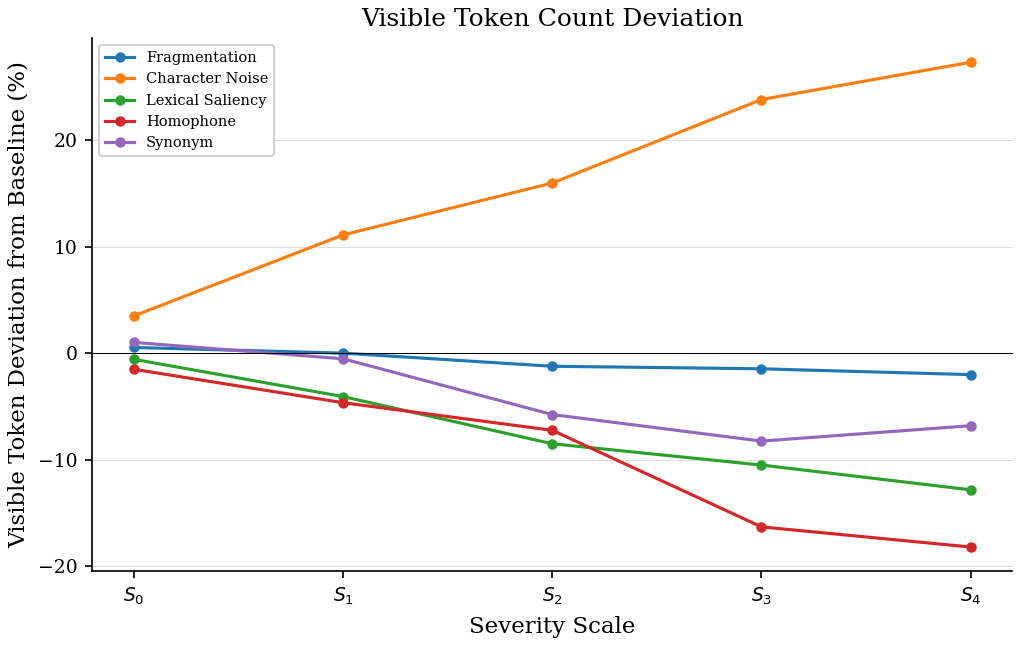

In [35]:
if not np.isnan(bl_tok_mean):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for corr in LABEL_LEVEL:
        sub = df[df.corruption == corr].groupby('severity')['token_count'].mean()
        dev = ((sub - bl_tok_mean) / bl_tok_mean * 100)
        ax.plot(dev.index, dev.values, marker='o', markersize=4, linewidth=1.5,
                color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Severity Scale')
    ax.set_ylabel('Visible Token Deviation from Baseline (%)')
    ax.set_title('Visible Token Count Deviation')
    ax.set_xticks(range(5))
    ax.set_xticklabels(['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$'])
    ax.legend(loc='upper left', framealpha=0.9, fontsize=7)
    style_ax(ax)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'fig_token_deviation.pdf'))
    fig.savefig(os.path.join(OUTPUT_DIR, 'fig_token_deviation.png'))
    plt.show()
else:
    print('Baseline token counts not available - skipping deviation plot.')

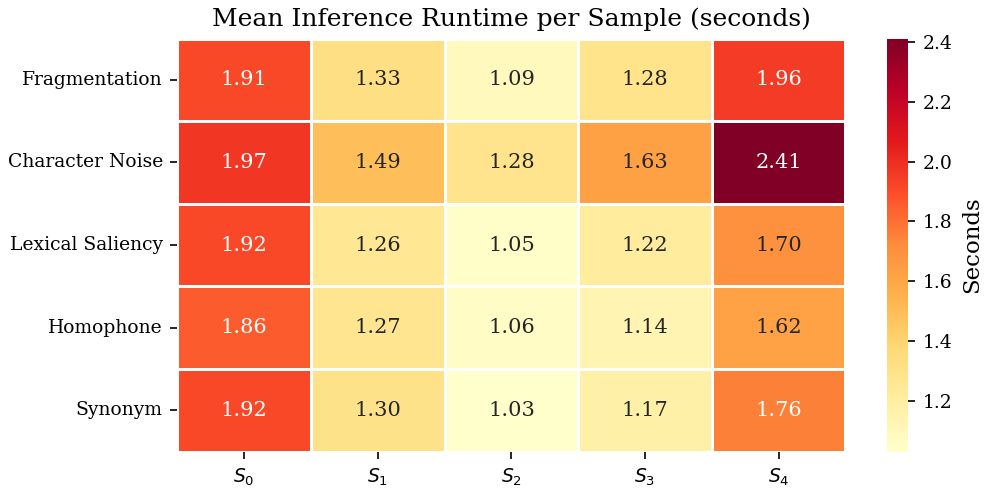

In [36]:
heat_rt = rt_pivot.copy()
heat_rt.columns = ['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$']

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(heat_rt, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Seconds'})
ax.set_title('Mean Inference Runtime per Sample (seconds)')
ax.set_ylabel('')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_runtime_heatmap.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_runtime_heatmap.png'))
plt.show()

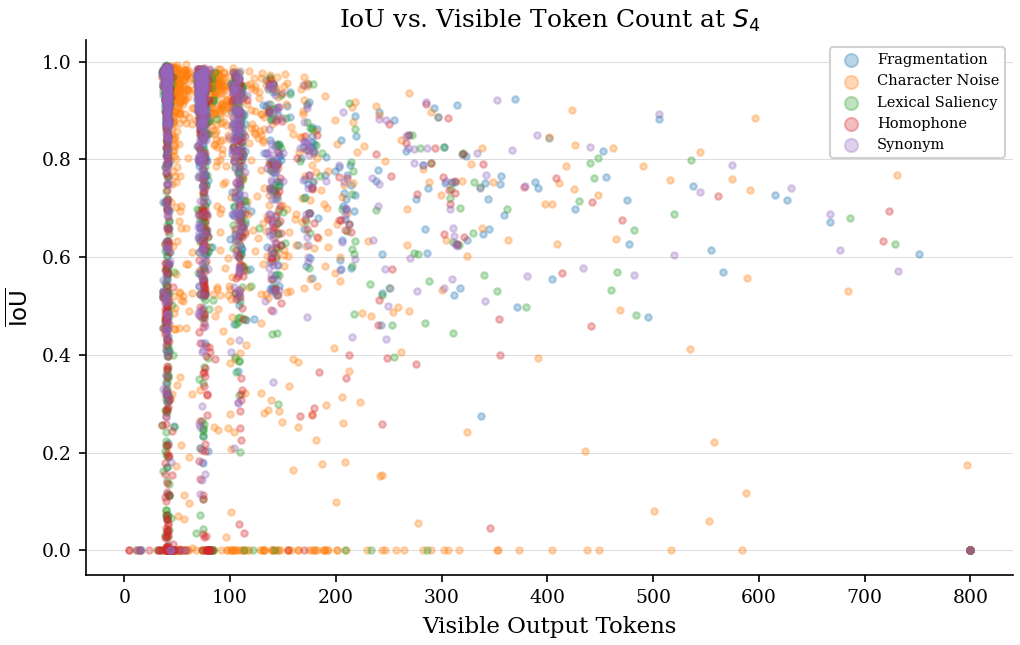

In [37]:
sev4_sub = df[df.severity == 4].copy()

fig, ax = plt.subplots(figsize=(7, 4.5))

for corr in LABEL_LEVEL:
    s = sev4_sub[sev4_sub.corruption == corr]
    ax.scatter(s['token_count'], s['IoU'], c=CORR_COLORS[corr],
               marker='o', s=10, alpha=0.3, label=NICE_NAMES.get(corr, corr))

ax.set_xlabel('Visible Output Tokens')
ax.set_ylabel('$\\overline{\\mathrm{IoU}}$')
ax.set_title('IoU vs. Visible Token Count at $S_4$')
ax.legend(loc='upper right', framealpha=0.9, fontsize=7, markerscale=2)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_iou_vs_tokens_sev4.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_iou_vs_tokens_sev4.png'))
plt.show()

## Complete Detection Failure (IoU = 0)

In [38]:
zero_iou = df[df['IoU'] == 0.0]

print(f'Total IoU=0 entries: {len(zero_iou)} / {len(df)} ({len(zero_iou)/len(df)*100:.2f}%)')
print()

zero_pivot = zero_iou.pivot_table(
    index='corruption', columns='severity', values='IoU', aggfunc='count'
).fillna(0).astype(int)
zero_pivot = zero_pivot.reindex([c for c in LABEL_LEVEL if c in zero_pivot.index])
zero_pivot['total'] = zero_pivot.sum(axis=1)
zero_pivot.index = [NICE_NAMES.get(c, c) for c in zero_pivot.index]

print('=== IoU=0 Count (Complete Detection Failure) ===')
display(zero_pivot)

Total IoU=0 entries: 440 / 18750 (2.35%)

=== IoU=0 Count (Complete Detection Failure) ===


severity,0,1,2,3,4,total
Fragmentation,1,6,4,7,13,31
Character Noise,2,7,24,48,93,174
Lexical Saliency,4,3,14,21,38,80
Homophone,4,9,19,42,54,128
Synonym,1,3,6,8,9,27


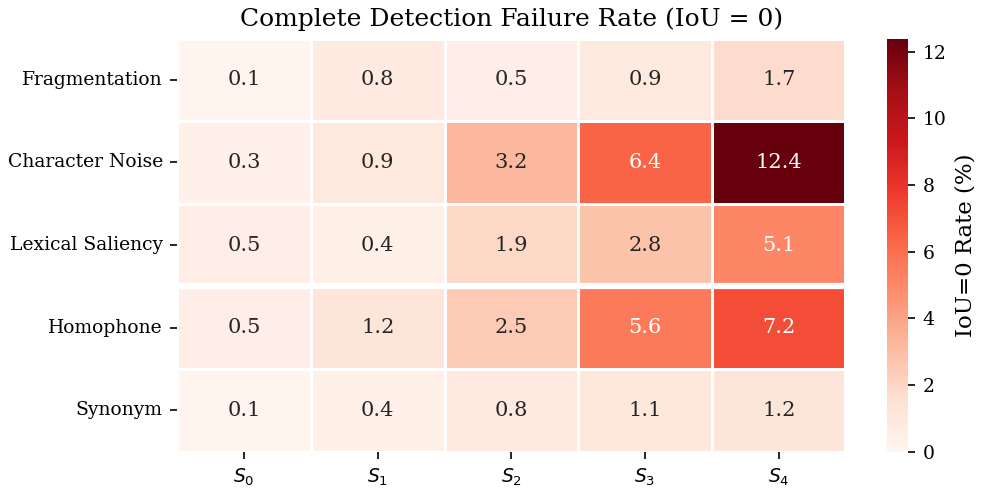

In [39]:
total_per_cell = df.groupby(['corruption', 'severity']).size().reset_index(name='total')
zero_per_cell = zero_iou.groupby(['corruption', 'severity']).size().reset_index(name='zeros')
rate = total_per_cell.merge(zero_per_cell, on=['corruption', 'severity'], how='left')
rate['zeros'] = rate['zeros'].fillna(0)
rate['zero_rate'] = (rate['zeros'] / rate['total'] * 100).round(1)

rate_pivot = rate.pivot_table(
    index='corruption', columns='severity', values='zero_rate'
).fillna(0)
rate_pivot = rate_pivot.reindex([c for c in LABEL_LEVEL if c in rate_pivot.index])
rate_pivot.index = [NICE_NAMES.get(c, c) for c in rate_pivot.index]
rate_pivot.columns = ['$S_0$', '$S_1$', '$S_2$', '$S_3$', '$S_4$']

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(rate_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'IoU=0 Rate (%)'})
ax.set_title('Complete Detection Failure Rate (IoU = 0)')
ax.set_ylabel('')

ax.axhline(3, color='white', lw=3)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_zero_iou_rate_heatmap.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_zero_iou_rate_heatmap.png'))
plt.show()